# Qn1

In [15]:
import torch
from torchvision import transforms,models
from PIL import Image

def preprocess_image(image_path):
    # Load the image
    img = Image.open(image_path).convert("RGB")

    # Standard preprocessing for ImageNet models
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    # Apply transforms
    input_tensor = preprocess(img)

    # Add batch dimension
    input_batch = input_tensor.unsqueeze(0)

    return input_tensor, input_batch

# Qn2

In [17]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()

input_tensor, input_batch = preprocess_image("flower.jpg")

with torch.no_grad():
    output = model(input_batch)
    predicted_class = output.argmax(1).item()

print("Predicted Class:", predicted_class)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\babuk/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:19<00:00, 5.25MB/s]


Predicted Class: 985


# Qn3

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 103s 1us/step


C:\Users\babuk\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/15
625/625 - 71s - 114ms/step - accuracy: 0.4315 - loss: 1.5655 - val_accuracy: 0.5490 - val_loss: 1.2480
Epoch 2/15
625/625 - 102s - 162ms/step - accuracy: 0.6037 - loss: 1.1255 - val_accuracy: 0.6299 - val_loss: 1.0554
Epoch 3/15
625/625 - 79s - 126ms/step - accuracy: 0.6675 - loss: 0.9457 - val_accuracy: 0.6754 - val_loss: 0.9296
Epoch 4/15
625/625 - 93s - 150ms/step - accuracy: 0.7088 - loss: 0.8277 - val_accuracy: 0.6792 - val_loss: 0.9265
Epoch 5/15
625/625 - 106s - 170ms/step - accuracy: 0.7372 - loss: 0.7444 - val_accuracy: 0.7073 - val_loss: 0.8423
Epoch 6/15
625/625 - 54s - 87ms/step - accuracy: 0.7649 - loss: 0.6747 - val_accuracy: 0.7117 - val_loss: 0.8413
Epoch 7/15
625/625 - 104s - 167ms/step - accuracy: 0.7862 - loss: 0.6068 - val_accuracy: 0.7234 - val_loss: 0.8252
Epoch 8/15
625/625 - 84s - 134ms/step - accuracy: 0.8081 - loss: 0.5488 - val_accuracy: 0.7257 - val_loss: 0.8442
Epoch 9/15
625/625 - 72s - 116ms/step - accuracy: 0.8274 - loss: 0.4918 - val_accuracy

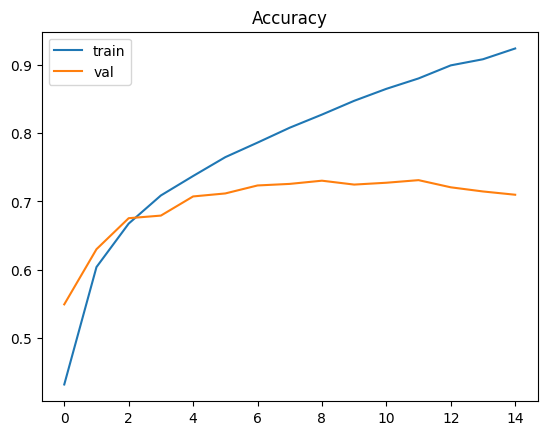

In [23]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()

# Qn4

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30, callbacks=[early_stop])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


C:\Users\babuk\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9093 - loss: 0.2974 - val_accuracy: 0.9636 - val_loss: 0.1136
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9557 - loss: 0.1465 - val_accuracy: 0.9707 - val_loss: 0.0945
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9644 - loss: 0.1145 - val_accuracy: 0.9720 - val_loss: 0.0880
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9697 - loss: 0.0970 - val_accuracy: 0.9783 - val_loss: 0.0757
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9732 - loss: 0.0859 - val_accuracy: 0.9794 - val_loss: 0.0729
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9767 - loss: 0.0755 - val_accuracy: 0.9795 - val_loss: 0.0717
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9780 - loss: 0.0707 - val_accuracy: 0.9819 - val_loss: 0.0675
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9799 - loss: 0.

# Qn5

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
for layer in base_model.layers:
    layer.trainable = False

y = base_model.output
y = Flatten()(y)
y = Dropout(0.5)(y)
y = Dense(128, activation='relu')(y)
output = Dense(1, activation='sigmoid')(y)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])